In [6]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

In [36]:
PRED_DIR = "/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg"
LABEL_DIR = "/Volumes/BACH2TB/Projects/SmallLesionMRI/labelsTs"
MODEL_NAMEs = [
    "SegResNet",
    "nnUNet",
    "UNETR",
    "SwinUNETR",
    "UMambaBot",
    "UMambaEnc"
]

def get_pred_paths(model_name, proba=False):
    model_pred_dir = os.path.join(PRED_DIR, model_name)
    file_ending = ".npz" if proba else ".nii.gz"
    fps = [os.path.join(model_pred_dir, fn) for fn in os.listdir(model_pred_dir) if fn.endswith(file_ending)]
    return fps

def get_gt_paths():
    return[os.path.join(LABEL_DIR, fn) for fn in os.listdir(LABEL_DIR) if fn.endswith(".nii.gz")]

def get_pred_paths_of_one_case_for_all_models(case_id="", proba=False):
    all_paths = {}
    for model_name in MODEL_NAMEs:
        model_paths = get_pred_paths(model_name, proba)
        case_paths = [fp for fp in model_paths if case_id in os.path.basename(fp)]
        if case_paths:
            all_paths[model_name] = case_paths[0]
        else:
            all_paths[model_name] = None
    return all_paths

In [37]:
model_name = "SegResNet"
segresnet_pred_paths = get_pred_paths(model_name, proba=True)
gt_paths = get_gt_paths()

segresnet_pred_paths, gt_paths

(['/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P13_T1.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P13_T2.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P26_T1.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P2_T1.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P2_T2.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P2_T3.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P2_T4.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P47_T1.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P49_T1.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P49_T2.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P52_T1.npz',
  '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P52_T2.npz'],
 ['/Volumes/BACH2TB/Projects/SmallLesionMRI/labelsTs/P13_T1.nii.gz',
  '/Volumes/BACH2TB/Pr

In [44]:
easy_case_paths = get_pred_paths_of_one_case_for_all_models("P49_T1", proba=True)
easy_case_paths

{'SegResNet': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P49_T1.npz',
 'nnUNet': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/nnUNet/P49_T1.npz',
 'UNETR': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/UNETR/P49_T1.npz',
 'SwinUNETR': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SwinUNETR/P49_T1.npz',
 'UMambaBot': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/UMambaBot/P49_T1.npz',
 'UMambaEnc': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/UMambaEnc/P49_T1.npz'}

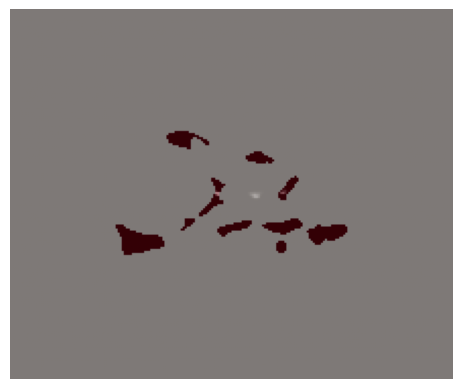

In [52]:
easy_pred = np.load(easy_case_paths["nnUNet"])["probabilities"][1]
easy_gt = nib.load("/Volumes/BACH2TB/Projects/SmallLesionMRI/labelsTs/P49_T1.nii.gz").get_fdata()
plt.imshow(easy_pred[..., 90], cmap="gray")
plt.imshow(easy_gt[..., 90], cmap="Reds", alpha=0.5)
plt.axis("off")
plt.show()

In [38]:
hard_case_paths = get_pred_paths_of_one_case_for_all_models("P49_T2", proba=True)
hard_case_paths

{'SegResNet': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SegResNet/P49_T2.npz',
 'nnUNet': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/nnUNet/P49_T2.npz',
 'UNETR': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/UNETR/P49_T2.npz',
 'SwinUNETR': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/SwinUNETR/P49_T2.npz',
 'UMambaBot': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/UMambaBot/P49_T2.npz',
 'UMambaEnc': '/Volumes/BACH2TB/Projects/SmallLesionMRI/MSLesSeg/UMambaEnc/P49_T2.npz'}

In [39]:
pred = np.load(hard_case_paths["nnUNet"])["probabilities"] # shape (2, 182, 218, 182)
p_lesion = pred[1]
gt = nib.load("/Volumes/BACH2TB/Projects/SmallLesionMRI/labelsTs/P49_T2.nii.gz").get_fdata()

In [40]:
pred.shape, gt.shape, p_lesion.shape

((2, 182, 218, 182), (182, 218, 182), (182, 218, 182))

In [41]:
np.min(p_lesion), np.max(p_lesion)

(np.float32(0.0), np.float32(1.0))

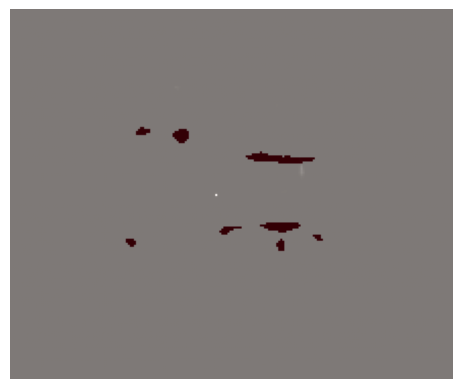

In [42]:
plt.imshow(p_lesion[..., 90], cmap="gray")
plt.imshow(gt[..., 90], cmap="Reds", alpha=0.5)
plt.axis("off")
plt.show()

In [33]:
eps = 1e-8
entropy = - (
    p_lesion * np.log(p_lesion + eps) +
    (1 - p_lesion) * np.log(1 - p_lesion + eps)
)
entropy.shape

(182, 218, 182)

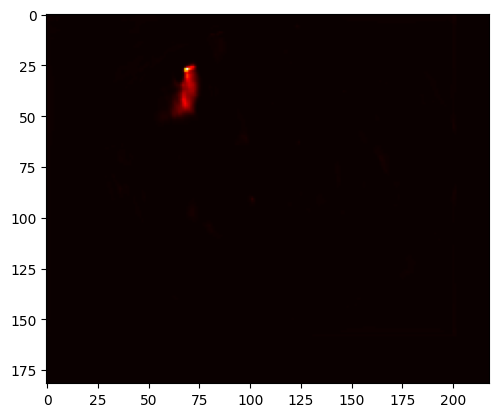

In [34]:
plt.imshow(entropy[..., 90], cmap="hot")